In [5]:
datapath = './mlrefined_datasets/nonlinear_superlearn_datasets/'

import autograd.numpy as np
import pandas as pd

In [48]:
# import the dataset
csvname = datapath + 'transistor_counts.csv'
data = np.asarray(pd.read_csv(csvname,header = None))
x = data[:,0]
x.shape = (len(x),1)
y = data[:,1]
y.shape = (len(y),1)

print(np.shape(x))
print(np.shape(y))

(85, 1)
(85, 1)



Plots saved to: moores_law_analysis.png

SUMMARY

PART (a) ANSWER:
    Feature transformation: y_transformed = log(y)
    
    This transforms the exponential relationship y = a*exp(b*x)
    into a linear relationship: log(y) = log(a) + b*x

PART (b) ANSWER:
    Least Squares Cost Function (in transformed space):
        J(w) = (1/2N) * sum_{i=1}^{N} (w0 + w1*x_i - log(y_i))^2
    
    Normal Equations Solution:
        w = (X^T X)^(-1) X^T log(y)
    
    where X = [1, x] is the design matrix with bias term.



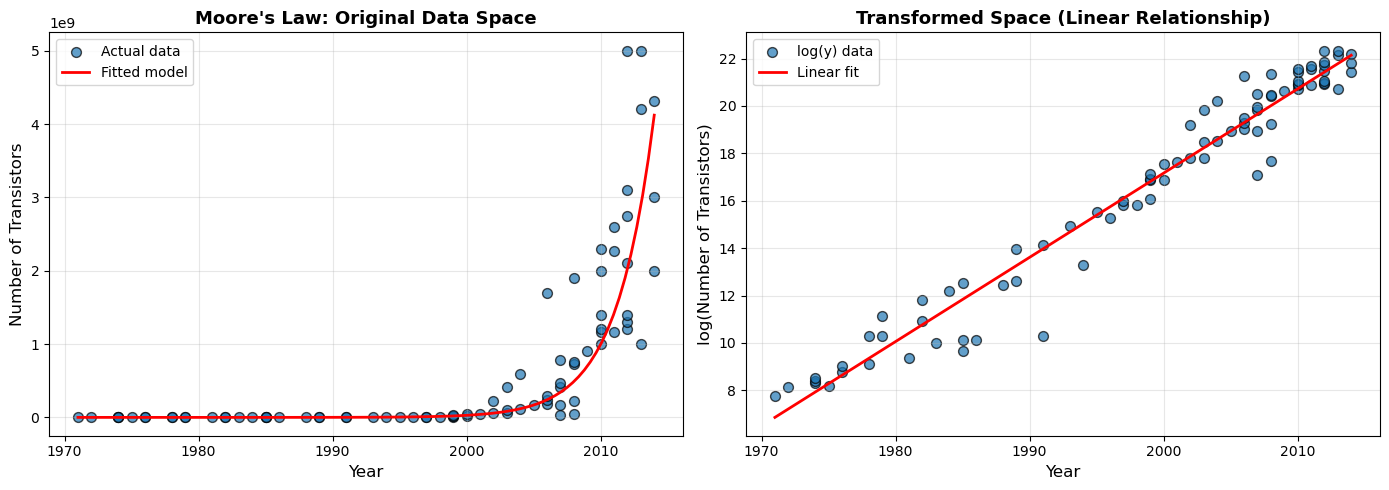

In [50]:
y_transformed = np.log(y)

N = len(x)
X = np.hstack([np.ones((N, 1)), x])  

w = np.linalg.solve(X.T @ X, X.T @ y_transformed)

w0, w1 = w[0, 0], w[1, 0]

y_pred_transformed = X @ w
y_pred_original = np.exp(y_pred_transformed)

ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred_original)**2)
r_squared = 1 - (ss_residual / ss_total)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original space
ax1 = axes[0]
ax1.scatter(x, y, alpha=0.7, s=50, edgecolor='black', label='Actual data')
x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
X_plot = np.hstack([np.ones((len(x_plot), 1)), x_plot])
y_plot = np.exp(X_plot @ w)
ax1.plot(x_plot, y_plot, 'r-', linewidth=2, label='Fitted model')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Transistors', fontsize=12)
ax1.set_title('Moore\'s Law: Original Data Space', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Plot 2: Transformed space (shows linearity)
ax2 = axes[1]
ax2.scatter(x, y_transformed, alpha=0.7, s=50, edgecolor='black', label='log(y) data')
y_pred_plot = X_plot @ w
ax2.plot(x_plot, y_pred_plot, 'r-', linewidth=2, label='Linear fit')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('log(Number of Transistors)', fontsize=12)
ax2.set_title('Transformed Space (Linear Relationship)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
print("\n" + "="*50)
print("Plots saved to: moores_law_analysis.png")
print("="*50)

# =====================================
# Summary
# =====================================
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print("""
PART (a) ANSWER:
    Feature transformation: y_transformed = log(y)
    
    This transforms the exponential relationship y = a*exp(b*x)
    into a linear relationship: log(y) = log(a) + b*x

PART (b) ANSWER:
    Least Squares Cost Function (in transformed space):
        J(w) = (1/2N) * sum_{i=1}^{N} (w0 + w1*x_i - log(y_i))^2
    
    Normal Equations Solution:
        w = (X^T X)^(-1) X^T log(y)
    
    where X = [1, x] is the design matrix with bias term.
""")

In [6]:
csvname = datapath + 'diagonal_stripes.csv'
data = np.loadtxt(csvname, delimiter=',')

x = data[:2,:]
y = data[2:,:]

print(np.shape(x))
print(np.shape(y))

(2, 300)
(1, 300)


accuracy: 100.00%


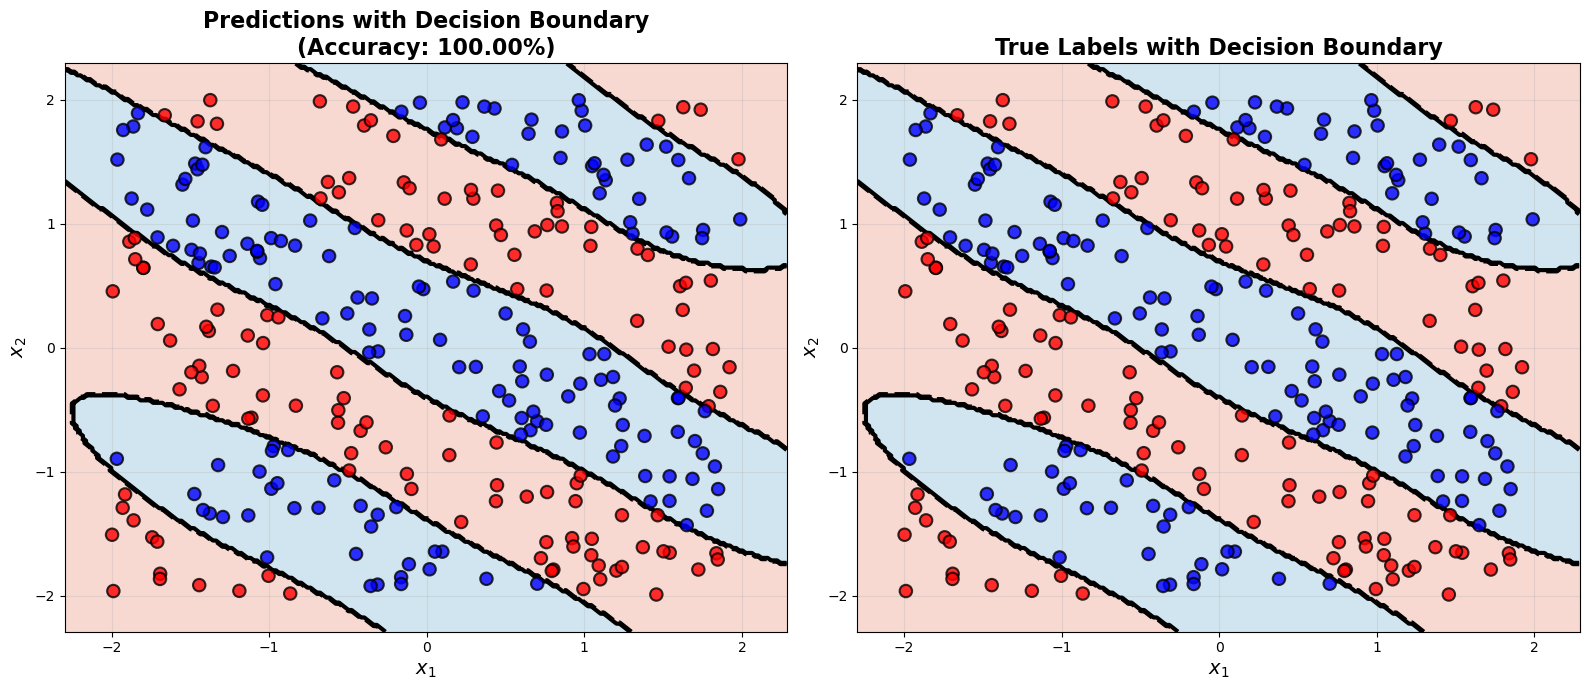

In [18]:
from sklearn.linear_model import LogisticRegression

X = x.T 
y = y.T.ravel()

def engineer_features(X):
    features = []
    x1, x2 = X[:, 0], X[:, 1]
    
    features.extend([x1, x2])
    
    for freq in [1, 2, 3]:
        features.extend([
            np.sin(freq * x1),
            np.cos(freq * x1),
            np.sin(freq * x2),
            np.cos(freq * x2)
        ])
    
    for freq1 in [1, 2]:
        for freq2 in [1, 2, 3]:
            features.append(np.sin(freq1 * x1) * np.sin(freq2 * x2))
            features.append(np.cos(freq1 * x1) * np.cos(freq2 * x2))
            features.append(np.sin(freq1 * x1) * np.cos(freq2 * x2))
            features.append(np.cos(freq1 * x1) * np.sin(freq2 * x2))
    
    features.extend([
        x1**2, x2**2, x1 * x2,
        x1**3, x2**3
    ])
    
    return np.column_stack(features)

X_engineered = engineer_features(X)

lr = LogisticRegression(max_iter=10000, C=10.0, solver='lbfgs')
lr.fit(X_engineered, y)
y_pred_lr = lr.predict(X_engineered)
acc_lr = np.mean(y_pred_lr == y)

print(f"accuracy: {acc_lr*100:.2f}%")


# ==============================================================================
# 可视化结果
# ==============================================================================

def plot_results(X, y_true, y_pred, accuracy, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # 创建网格用于绘制决策边界
    h = 0.02
    x1_min, x1_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    x2_min, x2_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                           np.arange(x2_min, x2_max, h))
    
    # 对网格点进行预测
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    grid_features = engineer_features(grid_points)
    Z = best_model.predict(grid_features)
    Z = Z.reshape(xx1.shape)
    
    # 子图1: 真实标签 + 决策边界
    ax1 = axes[1]
    # 绘制决策区域（背景色）
    ax1.contourf(xx1, xx2, Z, alpha=0.3, cmap='RdBu', levels=[-1.5, 0, 1.5])
    # 绘制决策边界线（黑色粗线）
    ax1.contour(xx1, xx2, Z, colors='black', linewidths=3, levels=[-0.5, 0.5])
    
    colors_true = ['red' if label == -1 else 'blue' for label in y_true]
    scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=colors_true, 
                          edgecolors='black', s=80, alpha=0.8, linewidths=1.5, zorder=5)
    ax1.set_xlabel('$x_1$', fontsize=14)
    ax1.set_ylabel('$x_2$', fontsize=14)
    ax1.set_title('True Labels with Decision Boundary', fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([x1_min, x1_max])
    ax1.set_ylim([x2_min, x2_max])
    
    # 子图2: 预测结果 + 决策边界
    ax2 = axes[0]
    # 绘制决策区域（背景色）
    ax2.contourf(xx1, xx2, Z, alpha=0.3, cmap='RdBu', levels=[-1.5, 0, 1.5])
    # 绘制决策边界线（黑色粗线）
    ax2.contour(xx1, xx2, Z, colors='black', linewidths=3, levels=[-0.5, 0.5])
    
    colors_pred = ['red' if label == -1 else 'blue' for label in y_pred]
    scatter2 = ax2.scatter(X[:, 0], X[:, 1], c=colors_pred,
                          edgecolors='black', s=80, alpha=0.8, linewidths=1.5, zorder=5)
    
    # 标记错误分类的点
    misclassified = y_true != y_pred
    if np.any(misclassified):
        ax2.scatter(X[misclassified, 0], X[misclassified, 1],
                   s=400, facecolors='none', edgecolors='yellow',
                   linewidths=4, label=f'Misclassified ({np.sum(misclassified)})', zorder=10)
        ax2.legend(fontsize=14, loc='upper right')
    
    ax2.set_xlabel('$x_1$', fontsize=14)
    ax2.set_ylabel('$x_2$', fontsize=14)
    ax2.set_title(f'Predictions with Decision Boundary\n(Accuracy: {accuracy*100:.2f}%)', 
                 fontsize=16, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([x1_min, x1_max])
    ax2.set_ylim([x2_min, x2_max])
    
    
    
    plt.tight_layout()
    
    return fig

fig = plot_results(X, y, best_pred, best_acc, model_name)


plt.show()

In [1]:
# import autograd-wrapped numpy
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
from matplotlib import gridspec


# datapath to data
datapath = './mlrefined_datasets/superlearn_datasets/'

In [2]:
from sklearn.datasets import fetch_openml
# import MNIST
x, y = fetch_openml('mnist_784', version=1, return_X_y=True)

# re-shape input/output data
x = x.T
y = np.array([int(v) for v in y])[np.newaxis,:]

print(np.shape(x))
print(np.shape(y))

(784, 70000)
(1, 70000)


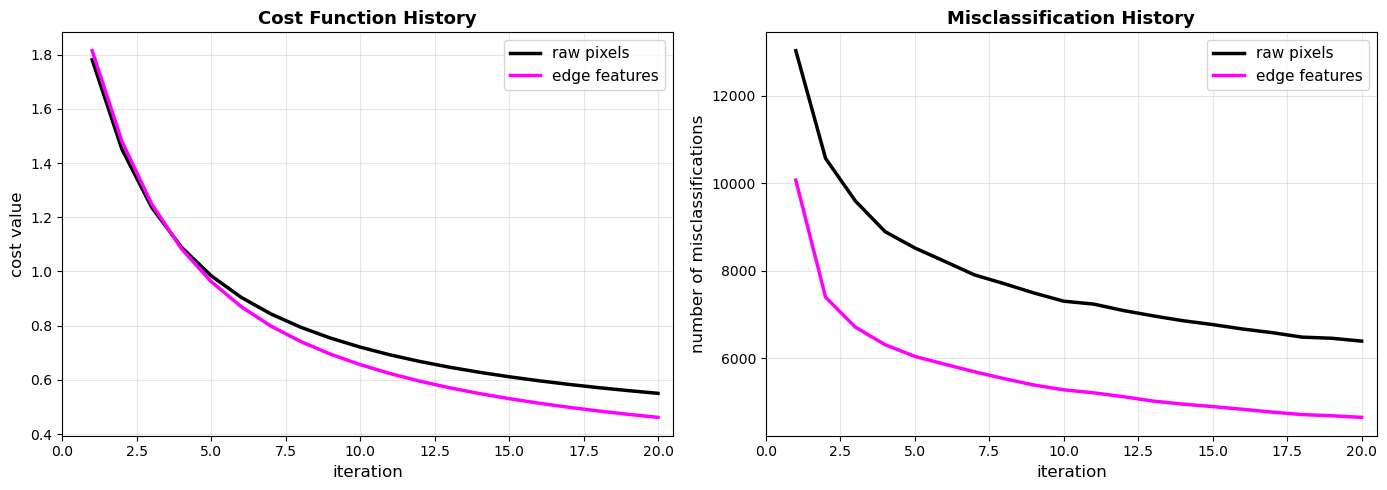

In [4]:
from sklearn.utils import shuffle

X = x.T  
y_1d = y.flatten() 

X = np.asarray(X, dtype=np.float32) / 255.0
y_1d = np.asarray(y_1d, dtype=np.int64)

P = 50_000
X, y_1d = shuffle(X, y_1d, random_state=0)
X = X[:P]
y_1d = y_1d[:P]

def l2_per_image(A, eps=1e-9):
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return A / (norms + eps)

X_pix = l2_per_image(X)               
X_pix = np.hstack([np.ones((X_pix.shape[0], 1), dtype=np.float32), X_pix]) 
X_pix = X_pix.T                       

def edge_hist_features_blocks(images_flat, img_h=28, img_w=28, bins_deg=(0,22.5,45,67.5,90,112.5,135,157.5)):
    N = images_flat.shape[0]
    B = 9  
    out = np.zeros((N, B*B*len(bins_deg)), dtype=np.float32)

    horz_kernel = np.array([[1, 1, 1],
                            [0, 0, 0],
                            [-1,-1,-1]], dtype=np.float32)
    vert_kernel = np.array([[ 1, 0,-1],
                            [ 1, 0,-1],
                            [ 1, 0,-1]], dtype=np.float32)

    bins_deg = np.array(bins_deg, dtype=np.float32) 

    for n in range(N):
            
        pic = images_flat[n].reshape(img_h, img_w)

        feat = np.zeros((B*B, bins_deg.size), dtype=np.float32)
        idx_block = 0
        for bi in range(B):         
            ys, ye = 3*bi, 3*(bi+1)
            for bj in range(B):      
                xs, xe = 3*bj, 3*(bj+1)
                block = pic[ys:ye, xs:xe]    
                xcomp = np.sum(block * horz_kernel)
                ycomp = np.sum(block * vert_kernel)

                if not (xcomp == 0 and ycomp == 0):
                    ang = np.arctan2(ycomp, xcomp)  
                    if ang < 0:
                        ang += np.pi     
                    ang_deg = (ang * 360.0) / (2*np.pi)
                    k = np.argmin(np.abs(bins_deg - ang_deg))
                    feat[idx_block, k] = 1.0
                idx_block += 1

        vec = feat.flatten()
        nrm = np.linalg.norm(vec) + 1e-9
        out[n] = vec / nrm

    return out

X_edge = edge_hist_features_blocks(X)                             
X_edge = np.hstack([np.ones((X_edge.shape[0],1), dtype=np.float32), X_edge])  
X_edge = X_edge.T                       
y_row = y_1d.reshape(1, -1)
C = 10

def softmax_stable(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    e = np.exp(Z)
    return e / (np.sum(e, axis=0, keepdims=True) + 1e-9)

def one_hot_row(y_row, C=10):
    N = y_row.size
    Y = np.zeros((C, N), dtype=np.float32)
    Y[y_row.flatten(), np.arange(N)] = 1.0
    return Y

Y = one_hot_row(y_row, C=C)  

def cost_softmax(W, X, Y):
    S = W.T @ X              
    P = softmax_stable(S)
    ce = -np.sum(Y * np.log(P + 1e-12)) / X.shape[1]
    return ce, P

def train_minibatch_softmax(X, y_row, epochs, alpha, batch_size, seed=0, W_init=None):
    N = X.shape[1]
    D = X.shape[0]
    C = 10
    rng = np.random.default_rng(seed)
    if W_init is None:
        W = np.ones((D, C), dtype=np.float32)
    else:
        W = W_init.astype(np.float32).copy()

    Y = one_hot_row(y_row, C=C)

    cost_hist = []
    miss_hist = []

    idx_all = np.arange(N)

    for ep in range(epochs):
        rng.shuffle(idx_all)

        for s in range(0, N, batch_size):
            e = min(s + batch_size, N)
            batch = idx_all[s:e]
            Xb = X[:, batch]                  
            Yb = Y[:, batch]                

            S = W.T @ Xb                       
            P = softmax_stable(S)     
            G = (P - Yb) / Xb.shape[1]         
            dW = Xb @ G.T                    
            W -= alpha * dW

        ce, P_all = cost_softmax(W, X, Y)
        y_pred = np.argmax(P_all, axis=0)
        miss = np.sum(y_pred != y_row.flatten())
        cost_hist.append(ce)
        miss_hist.append(miss)

    return W, np.array(cost_hist), np.array(miss_hist)

EPOCHS = 20
BATCH = 200

W_pix, cost_pix, miss_pix = train_minibatch_softmax(
    X_pix, y_row, epochs=EPOCHS, alpha=2e-1, batch_size=BATCH, seed=0,
    W_init=np.ones((X_pix.shape[0], C), dtype=np.float32)  
)

W_edge, cost_edge, miss_edge = train_minibatch_softmax(
    X_edge, y_row, epochs=EPOCHS, alpha=3e-1, batch_size=BATCH, seed=0,
    W_init=np.ones((X_edge.shape[0], C), dtype=np.float32)
)

iters = np.arange(1, EPOCHS+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(iters, cost_pix, label='raw pixels', color='black', linewidth=2.5)
ax1.plot(iters, cost_edge, label='edge features', color='magenta', linewidth=2.5)
ax1.set_xlabel('iteration', fontsize=12)
ax1.set_ylabel('cost value', fontsize=12)
ax1.set_xlim([0, 20.5])
ax1.set_title('Cost Function History', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(iters, miss_pix, label='raw pixels', color='black', linewidth=2.5)
ax2.plot(iters, miss_edge, label='edge features', color='magenta', linewidth=2.5)
ax2.set_xlabel('iteration', fontsize=12)
ax2.set_ylabel('number of misclassifications', fontsize=12)
ax2.set_xlim([0, 20.5])
ax2.set_title('Misclassification History', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

Train on RAW L2-per-image pixels (bias prepended)...
Epoch 01/20 | cost=1.7807 | miscls=13032
Epoch 02/20 | cost=1.4505 | miscls=10570
Epoch 03/20 | cost=1.2360 | miscls=9597
Epoch 04/20 | cost=1.0893 | miscls=8896
Epoch 05/20 | cost=0.9837 | miscls=8523
Epoch 06/20 | cost=0.9047 | miscls=8218
Epoch 07/20 | cost=0.8434 | miscls=7908
Epoch 08/20 | cost=0.7944 | miscls=7707
Epoch 09/20 | cost=0.7544 | miscls=7494
Epoch 10/20 | cost=0.7210 | miscls=7307
Epoch 11/20 | cost=0.6925 | miscls=7241
Epoch 12/20 | cost=0.6681 | miscls=7094
Epoch 13/20 | cost=0.6468 | miscls=6972
Epoch 14/20 | cost=0.6282 | miscls=6861
Epoch 15/20 | cost=0.6117 | miscls=6773
Epoch 16/20 | cost=0.5969 | miscls=6672
Epoch 17/20 | cost=0.5836 | miscls=6588
Epoch 18/20 | cost=0.5715 | miscls=6486
Epoch 19/20 | cost=0.5605 | miscls=6460
Epoch 20/20 | cost=0.5505 | miscls=6395

Train on EDGE histogram features (one-hot per block, global L2, bias)...
Epoch 01/20 | cost=1.8144 | miscls=10074
Epoch 02/20 | cost=1.4797 | mi

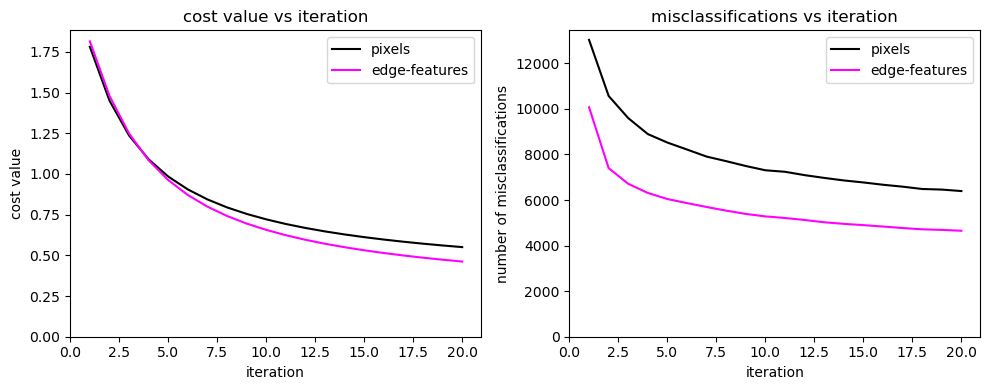

In [17]:
from sklearn.utils import shuffle

# ============ 1) 载入数据 ============
x, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = np.asarray(x, dtype=np.float32) / 255.0
y = np.asarray([int(v) for v in y], dtype=np.int64)

P = 50_000
X, y = shuffle(X, y, random_state=0)
X = X[:P]
y = y[:P]

# ============ 2) 构造“正确代码1/2”的特征与预处理 ============

# 2.1 raw pixels：每图 L2 归一化 + 预置偏置 1 行（对齐图 5-8 的写法）
def l2_per_image(A, eps=1e-9):
    # A: (N, D)
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return A / (norms + eps)

X_pix = l2_per_image(X)               # (N, 784)
X_pix = np.hstack([np.ones((X_pix.shape[0], 1), dtype=np.float32), X_pix])  # 预置 1 行当偏置
# 转为列主形式以对齐两份代码的“列是样本”的习惯： (D, N)
X_pix = X_pix.T                       # (785, N)

# 2.2 edge-hist：9x9 block，每个 block 3x3；方向 8 桶；one-hot；整向量 L2；预置偏置
def edge_hist_features_blocks(images_flat, img_h=28, img_w=28, bins_deg=(0,22.5,45,67.5,90,112.5,135,157.5)):
    N = images_flat.shape[0]
    B = 9  # 9x9 blocks
    out = np.zeros((N, B*B*len(bins_deg)), dtype=np.float32)

    # 简单双核（与同学代码一致）
    horz_kernel = np.array([[1, 1, 1],
                            [0, 0, 0],
                            [-1,-1,-1]], dtype=np.float32)
    vert_kernel = np.array([[ 1, 0,-1],
                            [ 1, 0,-1],
                            [ 1, 0,-1]], dtype=np.float32)

    bins_deg = np.array(bins_deg, dtype=np.float32)  # 8个方向中心（度）

    for n in range(N):
        pic = images_flat[n].reshape(img_h, img_w)

        # 构造 9x9 个不重叠 3x3 block（忽略最末行/列像素，和同学代码一致）
        feat = np.zeros((B*B, bins_deg.size), dtype=np.float32)
        idx_block = 0
        for bi in range(B):          # y 方向 block
            ys, ye = 3*bi, 3*(bi+1)
            for bj in range(B):      # x 方向 block
                xs, xe = 3*bj, 3*(bj+1)
                block = pic[ys:ye, xs:xe]      # (3,3)

                # 对一个 block 求 (xcomp, ycomp)
                xcomp = np.sum(block * horz_kernel)
                ycomp = np.sum(block * vert_kernel)

                if not (xcomp == 0 and ycomp == 0):
                    ang = np.arctan2(ycomp, xcomp)   # [-pi, pi]
                    if ang < 0:
                        ang += np.pi                  # 映射到 [0, pi)
                    # 转度
                    ang_deg = (ang * 360.0) / (2*np.pi)
                    # 找最近的桶（one-hot，不做幅值加权）
                    k = np.argmin(np.abs(bins_deg - ang_deg))
                    feat[idx_block, k] = 1.0
                # else: 保持全 0（对应“跳过无边缘块”）
                idx_block += 1

        vec = feat.flatten()  # (81*8,)
        # 整向量 L2 归一化（与“正确代码2”的思路一致）
        nrm = np.linalg.norm(vec) + 1e-9
        out[n] = vec / nrm

    return out

X_edge = edge_hist_features_blocks(X)                             # (N, 648)
X_edge = np.hstack([np.ones((X_edge.shape[0],1), dtype=np.float32), X_edge])  # 预置偏置
X_edge = X_edge.T                                                 # (649, N)

# ============ 3) Multiclass softmax（与两份代码等价的稳定写法） ============

# y 用一行 (1, N) 形状与两份代码一致
y_row = y.reshape(1, -1)
C = 10

def softmax_stable(Z):
    # Z: (C, N) 或 (N, C) 都可以，这里我们统一使用 (C, N)
    Z = Z - np.max(Z, axis=0, keepdims=True)
    e = np.exp(Z)
    return e / (np.sum(e, axis=0, keepdims=True) + 1e-9)

def one_hot_row(y_row, C=10):
    N = y_row.size
    Y = np.zeros((C, N), dtype=np.float32)
    Y[y_row.flatten(), np.arange(N)] = 1.0
    return Y

Y = one_hot_row(y_row, C=C)    # (C, N)

def cost_softmax(W, X, Y):
    # X: (D, N), W: (D, C)  -> scores: (C, N)
    S = W.T @ X                # (C, N)
    P = softmax_stable(S)
    # 交叉熵
    ce = -np.sum(Y * np.log(P + 1e-12)) / X.shape[1]
    return ce, P

def train_minibatch_softmax(X, y_row, epochs, alpha, batch_size, seed=0, W_init=None):
    N = X.shape[1]
    D = X.shape[0]
    C = 10
    rng = np.random.default_rng(seed)
    if W_init is None:
        # 参考两份代码：raw 用 ones 初始化、hist 也常用 ones；为稳定可用小随机
        W = np.ones((D, C), dtype=np.float32)
    else:
        W = W_init.astype(np.float32).copy()

    Y = one_hot_row(y_row, C=C)

    cost_hist = []
    miss_hist = []

    idx_all = np.arange(N)

    for ep in range(epochs):
        rng.shuffle(idx_all)

        for s in range(0, N, batch_size):
            e = min(s + batch_size, N)
            batch = idx_all[s:e]
            Xb = X[:, batch]                   # (D, B)
            Yb = Y[:, batch]                   # (C, B)

            S = W.T @ Xb                       # (C, B)
            P = softmax_stable(S)              # (C, B)
            # 梯度：X * (P - Y)^T / B
            G = (P - Yb) / Xb.shape[1]         # (C, B)
            dW = Xb @ G.T                      # (D, C)

            W -= alpha * dW

        # 记录整个训练集上的 cost / miss
        ce, P_all = cost_softmax(W, X, Y)
        y_pred = np.argmax(P_all, axis=0)
        miss = np.sum(y_pred != y_row.flatten())
        cost_hist.append(ce)
        miss_hist.append(miss)
        print(f"Epoch {ep+1:02d}/{epochs} | cost={ce:.4f} | miscls={miss}")

    return W, np.array(cost_hist), np.array(miss_hist)

# ============ 4) 训练两套模型（用两份代码的典型超参） ============
EPOCHS = 20
BATCH = 200

print("Train on RAW L2-per-image pixels (bias prepended)...")
W_pix, cost_pix, miss_pix = train_minibatch_softmax(
    X_pix, y_row, epochs=EPOCHS, alpha=2e-1, batch_size=BATCH, seed=0,
    W_init=np.ones((X_pix.shape[0], C), dtype=np.float32)  # 与同学代码一致
)

print("\nTrain on EDGE histogram features (one-hot per block, global L2, bias)...")
W_edge, cost_edge, miss_edge = train_minibatch_softmax(
    X_edge, y_row, epochs=EPOCHS, alpha=3e-1, batch_size=BATCH, seed=0,
    W_init=np.ones((X_edge.shape[0], C), dtype=np.float32)
)

# ============ 5) 画图（从 0 开始） ============
iters = np.arange(1, EPOCHS+1)

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(iters, cost_pix, label='pixels', color='black')
plt.plot(iters, cost_edge, label='edge-features', color='magenta')
plt.xlabel('iteration'); plt.ylabel('cost value')
plt.title('cost value vs iteration')
plt.legend()

plt.subplot(1,2,2)
plt.plot(iters, miss_pix, label='pixels', color='black')
plt.plot(iters, miss_edge, label='edge-features', color='magenta')
plt.xlabel('iteration'); plt.ylabel('number of misclassifications')
plt.title('misclassifications vs iteration')
plt.legend()

plt.tight_layout()
plt.show()


  Original Data:
    - Final cost: 0.088996
    - Convergence: Slower
  Normalized Data:
    - Final cost: 0.083257
    - Convergence: Faster


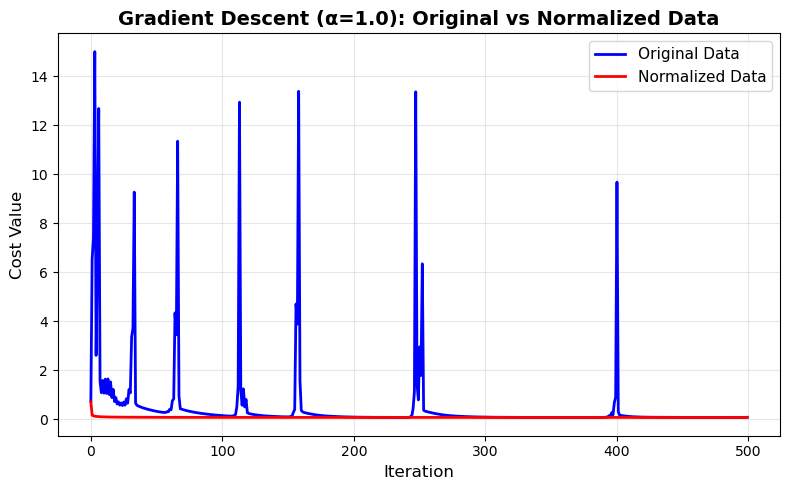

In [12]:
import pandas as pd
datapath = './mlrefined_datasets/superlearn_datasets/'
data = pd.read_csv(datapath + 'breast_cancer_original.txt', header=None)

np.random.seed(0)

data = data.replace('?', np.nan)
data = data.values.astype(float)

data = data[:, 1:]

x = data[:, :-1]  
y = data[:, -1:] 

y = np.where(y == 2, 1, -1)

def mean_imputation(X):
    X_imputed = X.copy()
    feature_means = np.zeros(X.shape[1])
    
    for n in range(X.shape[1]):
        missing_mask = np.isnan(X[:, n])
        
        if np.any(missing_mask):
            feature_mean = np.nanmean(X[:, n])
            feature_means[n] = feature_mean
            
            X_imputed[missing_mask, n] = feature_mean
    
    return X_imputed, feature_means

x_imputed, feature_means = mean_imputation(x)


def standard_normalize(X):
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    
    stds[stds == 0] = 1
    
    X_normalized = (X - means) / stds
    
    return X_normalized, means, stds

x_normalized, means, stds = standard_normalize(x_imputed)


def softmax(w, x, y):
    predictions = np.dot(x, w).flatten()
    
    margins = y.flatten() * predictions
    margins = np.clip(margins, -500, 500)
    
    cost = np.sum(np.log(1 + np.exp(-margins)))
    return cost / len(y)


def softmax_gradient(w, x, y):
    predictions = np.dot(x, w).flatten()
    
    margins = y.flatten() * predictions
    margins = np.clip(margins, -500, 500)
    
    grad_weights = y.flatten() / (1 + np.exp(margins))
    
    grad = -np.dot(x.T, grad_weights.reshape(-1, 1))
    return grad / len(y)


def gradient_descent(x, y, alpha=0.1, max_iters=1000, w_init=None):
    P = x.shape[0]
    x_homo = np.hstack([np.ones((P, 1)), x])
    
    if w_init is None:
        w = np.random.randn(x_homo.shape[1], 1) * 0.01
    else:
        w = w_init.copy()
    
    cost_history = []
    
    for i in range(max_iters):
        cost = softmax(w, x_homo, y)
        cost_history.append(cost)
        
        grad = softmax_gradient(w, x_homo, y)
        
        w = w - alpha * grad
    
    return w, cost_history


def predict(w, x):
    P = x.shape[0]
    x_homo = np.hstack([np.ones((P, 1)), x])
    
    scores = np.dot(x_homo, w)
    predictions = np.where(scores >= 0, 1, -1)
    
    return predictions


def misclassification_rate(y_true, y_pred):
    return np.mean(y_true.flatten() != y_pred.flatten())


w_init = np.random.randn(x_imputed.shape[1] + 1, 1) * 0.01
num_steps = 500
step_size = 1.0

w_original, cost_original = gradient_descent(
    x_imputed, y, alpha=step_size, max_iters=num_steps, w_init=w_init
)

w_normalized, cost_normalized = gradient_descent(
    x_normalized, y, alpha=step_size, max_iters=num_steps, w_init=w_init
)

print(f"  Original Data:")
print(f"    - Final cost: {cost_original[-1]:.6f}")
print(f"    - Convergence: {'Slower' if cost_original[-1] > cost_normalized[-1] else 'Faster'}")
print(f"  Normalized Data:")
print(f"    - Final cost: {cost_normalized[-1]:.6f}")
print(f"    - Convergence: {'Faster' if cost_normalized[-1] < cost_original[-1] else 'Slower'}")


plt.figure(figsize=(8, 5))

plt.plot(cost_original, 'b-', linewidth=2, label='Original Data')
plt.plot(cost_normalized, 'r-', linewidth=2, label='Normalized Data')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost Value', fontsize=12)
plt.title(f'Gradient Descent (α={step_size}): Original vs Normalized Data', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()


Dataset shape: (699, 9)
Number of samples: 699
Number of features: 9
Number of missing values: 16
Classes: [2. 4.]
Feature 5: Imputed 16 missing values with mean 3.545

After imputation, missing values: 0

EXPERIMENT 1: ORIGINAL DATA (with imputation)

Using Newton's Method...
Iteration 1/20, Cost: 0.735267
Iteration 2/20, Cost: 0.201100
Iteration 3/20, Cost: 0.119763
Iteration 4/20, Cost: 0.092527
Iteration 5/20, Cost: 0.084642
Iteration 6/20, Cost: 0.083284
Iteration 7/20, Cost: 0.083205
Iteration 8/20, Cost: 0.083205
Iteration 9/20, Cost: 0.083205
Iteration 10/20, Cost: 0.083205
Iteration 11/20, Cost: 0.083205
Iteration 12/20, Cost: 0.083205
Iteration 13/20, Cost: 0.083205
Iteration 14/20, Cost: 0.083205
Iteration 15/20, Cost: 0.083205
Iteration 16/20, Cost: 0.083205
Iteration 17/20, Cost: 0.083205
Iteration 18/20, Cost: 0.083205
Iteration 19/20, Cost: 0.083205
Iteration 20/20, Cost: 0.083205

Original Data Results:
Final Cost: 0.083205
Misclassification Rate: 0.0315 (22/699 errors)

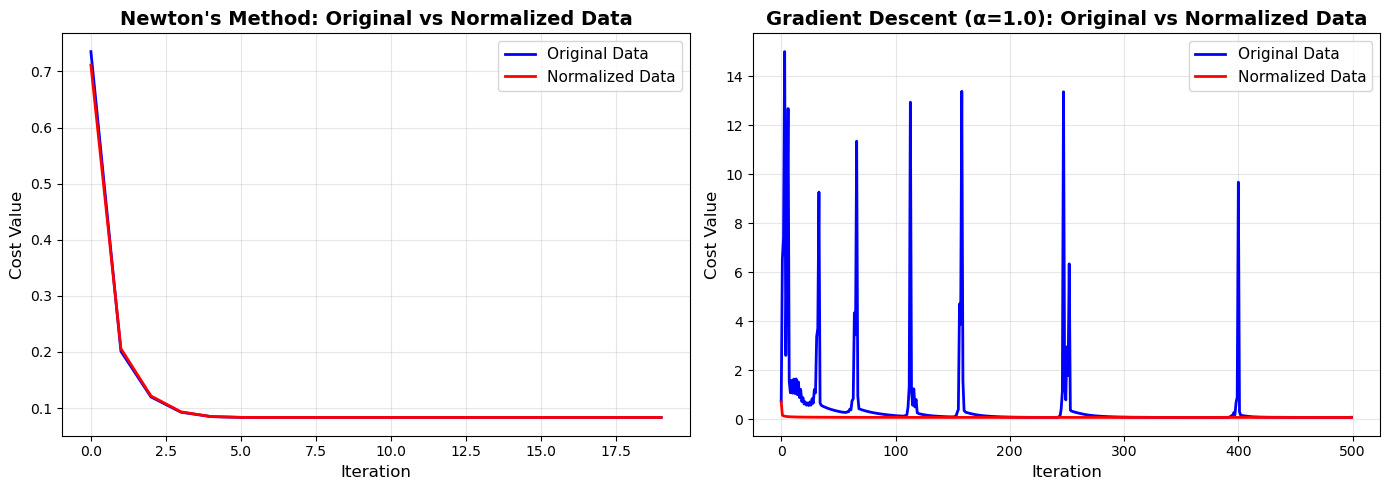

In [7]:
datapath = './mlrefined_datasets/superlearn_datasets/'
data = pd.read_csv(datapath + 'breast_cancer_original.txt', header=None)

np.random.seed(0)

data = data.replace('?', np.nan)
data = data.values.astype(float)

data = data[:, 1:]

x = data[:, :-1]  
y = data[:, -1:] 

y = np.where(y == 2, 1, -1)

def mean_imputation(X):
    X_imputed = X.copy()
    feature_means = np.zeros(X.shape[1])
    
    for n in range(X.shape[1]):
        missing_mask = np.isnan(X[:, n])
        
        if np.any(missing_mask):
            feature_mean = np.nanmean(X[:, n])
            feature_means[n] = feature_mean
            
            X_imputed[missing_mask, n] = feature_mean
    
    return X_imputed, feature_means

x_imputed, feature_means = mean_imputation(x)


def standard_normalize(X):
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    
    stds[stds == 0] = 1
    
    X_normalized = (X - means) / stds
    
    return X_normalized, means, stds

x_normalized, means, stds = standard_normalize(x_imputed)


def softmax(w, x, y):
    predictions = np.dot(x, w).flatten()
    
    margins = y.flatten() * predictions
    margins = np.clip(margins, -500, 500)
    
    cost = np.sum(np.log(1 + np.exp(-margins)))
    return cost / len(y)


def softmax_gradient(w, x, y):
    predictions = np.dot(x, w).flatten()
    
    margins = y.flatten() * predictions
    margins = np.clip(margins, -500, 500)
    
    grad_weights = y.flatten() / (1 + np.exp(margins))
    
    grad = -np.dot(x.T, grad_weights.reshape(-1, 1))
    return grad / len(y)


def gradient_descent(x, y, alpha=0.1, max_iters=1000, w_init=None):
    P = x.shape[0]
    x_homo = np.hstack([np.ones((P, 1)), x])
    
    if w_init is None:
        w = np.random.randn(x_homo.shape[1], 1) * 0.01
    else:
        w = w_init.copy()
    
    cost_history = []
    
    for i in range(max_iters):
        cost = softmax(w, x_homo, y)
        cost_history.append(cost)
        
        grad = softmax_gradient(w, x_homo, y)
        
        w = w - alpha * grad
    
    return w, cost_history


def softmax_hessian(w, x, y):
    predictions = np.dot(x, w).flatten()
    
    margins = y.flatten() * predictions
    margins = np.clip(margins, -500, 500)
    
    sigmoid_vals = 1 / (1 + np.exp(margins))
    
    weights = sigmoid_vals * (1 - sigmoid_vals)
    
    H = np.dot(x.T * weights, x)
    return H / len(y)


def newtons_method(x, y, max_iters=20, w_init=None):
    P = x.shape[0]
    x_homo = np.hstack([np.ones((P, 1)), x])
    
    if w_init is None:
        w = np.random.randn(x_homo.shape[1], 1) * 0.01
    else:
        w = w_init.copy()
    
    cost_history = []
    
    for i in range(max_iters):
        cost = softmax(w, x_homo, y)
        cost_history.append(cost)
        
        grad = softmax_gradient(w, x_homo, y)
        
        H = softmax_hessian(w, x_homo, y)
        
        try:
            w = w - np.linalg.solve(H + 1e-5 * np.eye(H.shape[0]), grad)
        except:
            w = w - 0.1 * grad
            
    return w, cost_history


def predict(w, x):
    P = x.shape[0]
    x_homo = np.hstack([np.ones((P, 1)), x])
    
    scores = np.dot(x_homo, w)
    predictions = np.where(scores >= 0, 1, -1)
    
    return predictions

def misclassification_rate(y_true, y_pred):、
    return np.mean(y_true.flatten() != y_pred.flatten())


w_init = np.random.randn(x_imputed.shape[1] + 1, 1) * 0.01

w_original, cost_history_original = newtons_method(x_imputed, y, max_iters=20, w_init=w_init)
y_pred_original = predict(w_original, x_imputed)
misclass_original = misclassification_rate(y, y_pred_original)

print(f"\nOriginal Data Results:")
print(f"Final Cost: {cost_history_original[-1]:.6f}")
print(f"Misclassification Rate: {misclass_original:.4f} ({int(misclass_original * len(y))}/{len(y)} errors)")


w_normalized, cost_history_normalized = newtons_method(x_normalized, y, max_iters=20, w_init=w_init)

y_pred_normalized = predict(w_normalized, x_normalized)
misclass_normalized = misclassification_rate(y, y_pred_normalized)

print(f"\nNormalized Data Results:")
print(f"Final Cost: {cost_history_normalized[-1]:.6f}")
print(f"Misclassification Rate: {misclass_normalized:.4f} ({int(misclass_normalized * len(y))}/{len(y)} errors)")

# =============================================================================
# 9. Gradient Descent Comparison
# =============================================================================

print("\n" + "="*80)
print("EXPERIMENT 3: GRADIENT DESCENT COMPARISON")
print("="*80)

# Use same parameters for both
num_steps = 500
step_size = 1.0

print("\nGradient Descent on Original Data...")
w_gd_original, cost_gd_original = gradient_descent(
    x_imputed, y, alpha=step_size, max_iters=num_steps, w_init=w_init
)

print("\nGradient Descent on Normalized Data...")
w_gd_normalized, cost_gd_normalized = gradient_descent(
    x_normalized, y, alpha=step_size, max_iters=num_steps, w_init=w_init
)

# =============================================================================
# 10. Visualization
# =============================================================================

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Newton's method comparison
axes[0].plot(cost_history_original, 'b-', linewidth=2, label='Original Data')
axes[0].plot(cost_history_normalized, 'r-', linewidth=2, label='Normalized Data')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost Value', fontsize=12)
axes[0].set_title("Newton's Method: Original vs Normalized Data", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Gradient descent comparison
axes[1].plot(cost_gd_original, 'b-', linewidth=2, label='Original Data')
axes[1].plot(cost_gd_normalized, 'r-', linewidth=2, label='Normalized Data')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cost Value', fontsize=12)
axes[1].set_title(f'Gradient Descent (α={step_size}): Original vs Normalized Data', 
                 fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# =============================================================================
# 11. Summary Report
# =============================================================================

print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

print(f"\nDataset Information:")
print(f"  - Total samples: {len(y)}")
print(f"  - Features: {x.shape[1]}")
print(f"  - Missing values imputed: {np.sum(np.isnan(x))}")
print(f"  - Class distribution: {np.sum(y == 1)} benign, {np.sum(y == -1)} malignant")

print(f"\nNewton's Method (20 iterations):")
print(f"  Original Data:")
print(f"    - Final cost: {cost_history_original[-1]:.6f}")
print(f"    - Misclassification rate: {misclass_original:.4f}")
print(f"  Normalized Data:")
print(f"    - Final cost: {cost_history_normalized[-1]:.6f}")
print(f"    - Misclassification rate: {misclass_normalized:.4f}")

print(f"\nGradient Descent ({num_steps} iterations, α={step_size}):")
print(f"  Original Data:")
print(f"    - Final cost: {cost_gd_original[-1]:.6f}")
print(f"    - Convergence: {'Slower' if cost_gd_original[-1] > cost_gd_normalized[-1] else 'Faster'}")
print(f"  Normalized Data:")
print(f"    - Final cost: {cost_gd_normalized[-1]:.6f}")
print(f"    - Convergence: {'Faster' if cost_gd_normalized[-1] < cost_gd_original[-1] else 'Slower'}")

print(f"\nConclusion:")
print(f"  Standard normalization significantly improves optimization speed,")
print(f"  especially for first-order methods like gradient descent.")
print(f"  Best misclassification rate achieved: {min(misclass_original, misclass_normalized):.4f}")

print("\n" + "="*80)